# 🎭 Mask Detection CNN — TensorFlow
**Dataset:** `with_mask` (3700) | `without_mask` (3800)  
**Architecture:** Custom CNN + optional Transfer Learning (MobileNetV2)

## 1. Mount Google Drive & Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────
data_path = '/content/drive/MyDrive/mask/data'
CHECKPOINT_PATH = '/content/drive/MyDrive/mask/best_model.keras'
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────
IMG_SIZE    = (128, 128)   # resize all images to this
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
VAL_SPLIT   = 0.15         # 15 % validation
TEST_SPLIT  = 0.10         # 10 % test  (taken from non-validation pool)
SEED        = 42
CLASSES     = ['with_mask', 'without_mask']

# ── Architecture choice ────────────────────────────────────────────────
USE_TRANSFER_LEARNING = False  # Set True to use MobileNetV2 backbone

print('Config ready ✓')

Config ready ✓


## 3. Dataset Exploration

  with_mask           : 3725 images
  without_mask        : 3828 images


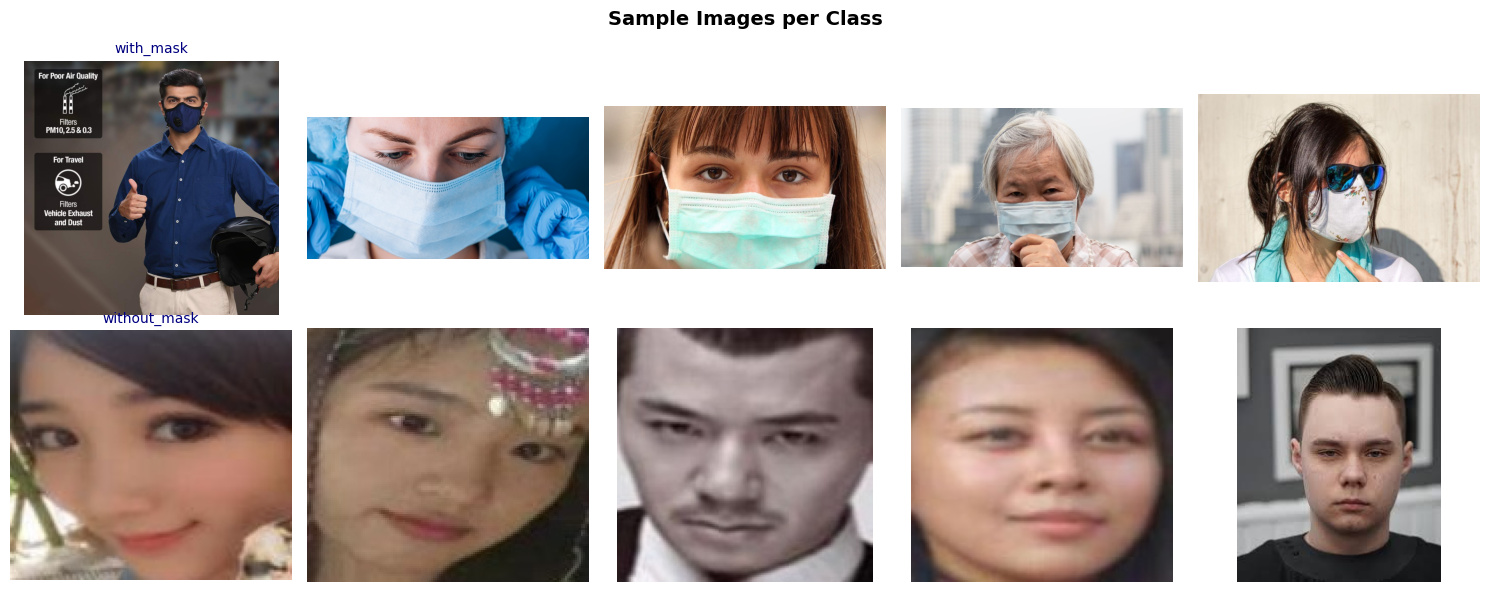

In [4]:
for cls in CLASSES:
    cls_path = os.path.join(data_path, cls)
    n = len(os.listdir(cls_path))
    print(f'  {cls:20s}: {n} images')

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(data_path, cls)
    files = os.listdir(cls_path)[:5]
    for col, fname in enumerate(files):
        img = plt.imread(os.path.join(cls_path, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, color='navy')
plt.tight_layout()
plt.show()

## 4. Load Entire Dataset into RAM
**Why?** Reading images one-by-one from Google Drive each epoch is the #1 cause of slow training (Drive I/O bottleneck).  
Loading everything into RAM once means the GPU is fed from memory — epochs drop from ~17 min to ~10–30 sec.

In [5]:
from tensorflow.keras.preprocessing import image as keras_image
from sklearn.model_selection import train_test_split
import glob

def load_dataset(data_path, classes, img_size):
    """Read all images into RAM as float32 arrays. Done once — fast forever."""
    X, y = [], []
    for label, cls in enumerate(classes):
        cls_dir = os.path.join(data_path, cls)
        files = glob.glob(os.path.join(cls_dir, '*'))
        print(f'  Loading {cls}: {len(files)} images...', end=' ')
        for fpath in files:
            try:
                img = keras_image.load_img(fpath, target_size=img_size)
                X.append(keras_image.img_to_array(img))
                y.append(label)
            except Exception:
                pass   # skip corrupted files
        print('done')
    X = np.array(X, dtype='float32') / 255.0
    y = np.array(y, dtype='float32')
    return X, y

print('Loading dataset into RAM (one-time cost)...')
X, y = load_dataset(data_path, CLASSES, IMG_SIZE)
print(f'\nX shape : {X.shape}  ({X.nbytes / 1e6:.1f} MB)')
print(f'y shape : {y.shape}  — classes: {dict(zip(CLASSES, [int((y==i).sum()) for i in range(len(CLASSES))]))}')

# ── Train / Val split ─────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VAL_SPLIT, random_state=SEED, stratify=y
)
print(f'\nTrain : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')

Loading dataset into RAM (one-time cost)...
  Loading with_mask: 3725 images... done
  Loading without_mask: 3828 images... done

X shape : (7553, 128, 128, 3)  (1485.0 MB)
y shape : (7553,)  — classes: {'with_mask': 3725, 'without_mask': 3828}

Train : 6420 samples
Val   : 1133 samples


## 4b. Build tf.data Pipelines (prefetch to GPU)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X, y, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)  # prefetch keeps GPU busy
    return ds

train_ds = make_dataset(X_train, y_train, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')
print('tf.data pipelines ready ✓')

Train batches : 201
Val   batches : 36
tf.data pipelines ready ✓


## 5. Model Architecture

In [7]:
def build_custom_cnn(input_shape=(128, 128, 3)):
    """Custom CNN with BatchNorm + Dropout for mask classification."""
    model = models.Sequential([
        # ── Block 1: 32 filters ────────────────────────────────────────
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # ── Block 2: 64 filters ────────────────────────────────────────
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # ── Block 3: 128 filters ───────────────────────────────────────
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.35),

        # ── Block 4: 256 filters ───────────────────────────────────────
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.40),

        # ── Classifier head ───────────────────────────────────────────
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(1, activation='sigmoid')   # Binary output
    ], name='MaskCNN')
    return model


def build_transfer_model(input_shape=(128, 128, 3)):
    """MobileNetV2 backbone + custom head."""
    base = MobileNetV2(input_shape=input_shape, include_top=False,
                       weights='imagenet')
    base.trainable = False  # Freeze initially

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='MaskMobileNetV2')


# ── Select architecture ────────────────────────────────────────────────
if USE_TRANSFER_LEARNING:
    model = build_transfer_model(input_shape=(*IMG_SIZE, 3))
else:
    model = build_custom_cnn(input_shape=(*IMG_SIZE, 3))

model.summary()

Model: "MaskCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 652,065 (2.49 MB)

 Trainable params: 650,145 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 6. Compile & Callbacks

In [8]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

cb_list = [
    # Save best model by val_accuracy
    callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR on plateau
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Stop early if no improvement for 10 epochs
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

print('Model compiled and callbacks ready ✓')

Model compiled and callbacks ready ✓


## 7. Class Weights (handle mild imbalance)

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

Class weights: {0: np.float64(1.0138976626658245), 1: np.float64(0.986478180700676)}


## 8. Training

In [10]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=cb_list,
    class_weight=class_weight_dict
)

Epoch 1/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7138 - auc: 0.7810 - loss: 0.6436 - precision: 0.7226 - recall: 0.6967
Epoch 1: val_accuracy improved from None to 0.50662, saving model to /content/drive/MyDrive/mask/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/mask/best_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 55s 145ms/step - accuracy: 0.7431 - auc: 0.8114 - loss: 0.5812 - precision: 0.7581 - recall: 0.7243 - val_accuracy: 0.5066 - val_auc: 0.7707 - val_loss: 1.4123 - val_precision: 0.5066 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
200/201 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8185 - auc: 0.8982 - loss: 0.4132 - precision: 0.8238 - recall: 0.8080
Epoch 2: val_accuracy improved from 0.50662 to 0.54281, saving model to /content/drive/MyDrive/mask/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/mask/best_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.8427 - auc: 0.918

## 9. Training Curves

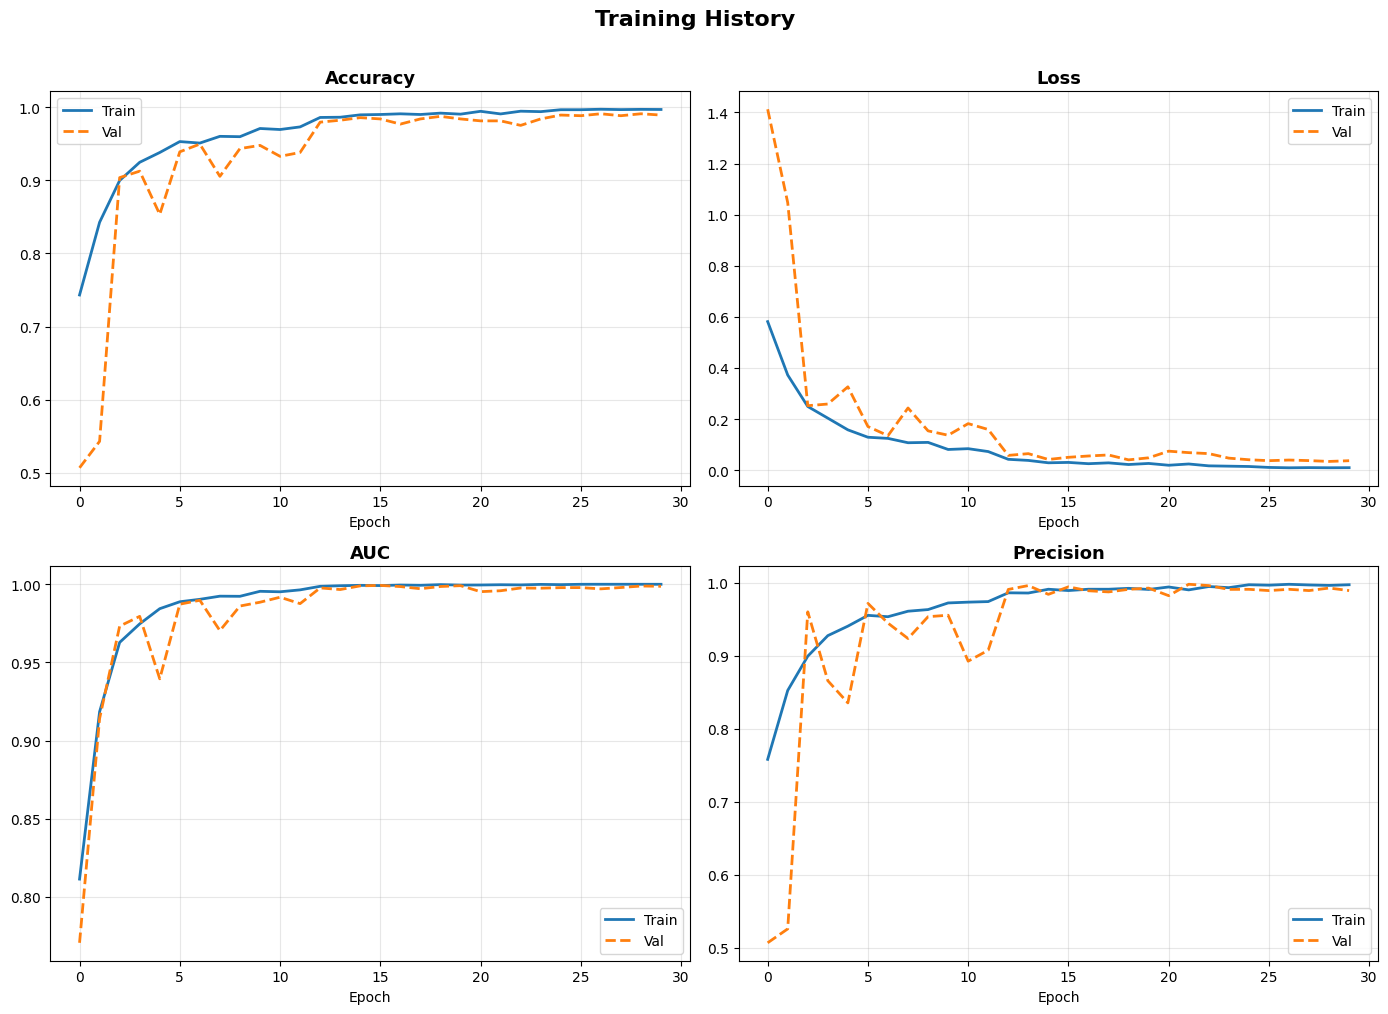

In [11]:
def plot_history(history):
    metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss'),
               ('auc', 'AUC'), ('precision', 'Precision')]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for ax, (key, title) in zip(axes, metrics):
        ax.plot(history.history[key], label='Train', linewidth=2)
        ax.plot(history.history[f'val_{key}'], label='Val',
                linewidth=2, linestyle='--')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    plt.suptitle('Training History', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_history(history)

## 10. Evaluation on Validation Set

In [12]:
# Load best saved model
best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

# Evaluate
results = best_model.evaluate(val_ds, verbose=1)
metric_names = best_model.metrics_names
print('\n── Best Model Metrics ──')
for name, val in zip(metric_names, results):
    print(f'  {name:12s}: {val:.4f}')

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9912 - auc: 0.9970 - loss: 0.0394 - precision: 0.9913 - recall: 0.9913

── Best Model Metrics ──
  loss        : 0.0394
  compile_metrics: 0.9912


## 11. Confusion Matrix & Classification Report

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

── Classification Report ──
              precision    recall  f1-score   support

   with_mask       0.99      0.99      0.99       559
without_mask       0.99      0.99      0.99       574

    accuracy                           0.99      1133
   macro avg       0.99      0.99      0.99      1133
weighted avg       0.99      0.99      0.99      1133



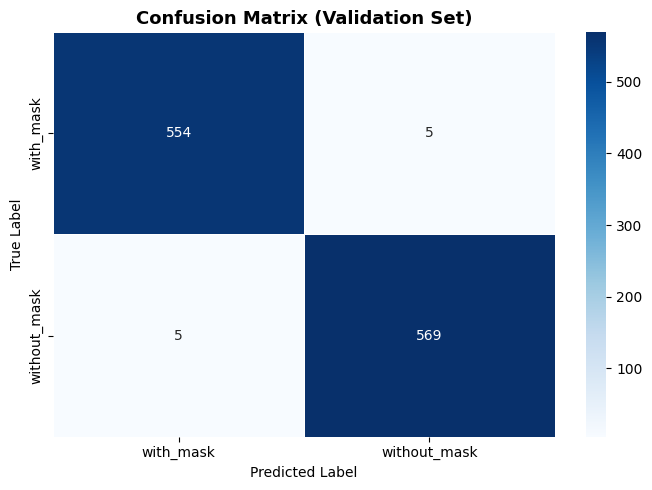

In [13]:
#val_gen.reset()
y_pred_proba = best_model.predict(val_ds, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = y_val.astype(int)

# Classification report
print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix (Validation Set)', fontsize=13,
             fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 12. Fine-Tuning (Transfer Learning Only)

In [14]:
if USE_TRANSFER_LEARNING:
    print('Unfreezing top 40 layers of MobileNetV2 for fine-tuning...')
    base_model = best_model.layers[1]   # MobileNetV2 layer
    base_model.trainable = True
    for layer in base_model.layers[:-40]:
        layer.trainable = False

    best_model.compile(
        optimizer=optimizers.Adam(learning_rate=LR / 10),  # lower LR
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    fine_tune_history = best_model.fit(
        train_gen,
        epochs=15,
        validation_data=val_gen,
        callbacks=cb_list,
        class_weight=class_weight_dict
    )
    plot_history(fine_tune_history)
else:
    print('Fine-tuning skipped (USE_TRANSFER_LEARNING=False)')

Fine-tuning skipped (USE_TRANSFER_LEARNING=False)


## 13. Predict on a Single Image

In [15]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_image(img_path, model, img_size=IMG_SIZE, threshold=0.5):
    """Predict mask/no-mask for a single image."""
    img = keras_image.load_img(img_path, target_size=img_size)
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    prob = model.predict(arr, verbose=0)[0][0]
    label = CLASSES[int(prob > threshold)]
    confidence = prob if label == 'without_mask' else 1 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(keras_image.load_img(img_path))
    color = 'red' if label == 'without_mask' else 'green'
    plt.title(f'{label}\nConfidence: {confidence:.2%}',
              color=color, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.show()
    return label, confidence

# ── Example usage (replace with any image path) ───────────────────────
# sample_img = '/content/drive/MyDrive/mask/data/with_mask/image1.jpg'
# predict_image(sample_img, best_model)
print('predict_image() function ready — replace sample_img path and run!')

predict_image() function ready — replace sample_img path and run!


## 14. Save Final Model

In [16]:
final_path = '/content/drive/MyDrive/mask/mask_cnn_final.keras'
best_model.save(final_path)
print(f'Model saved to: {final_path}')

# Also export as TFLite for deployment
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
tflite_path = '/content/drive/MyDrive/mask/mask_cnn.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model saved to: {tflite_path}')

Model saved to: /content/drive/MyDrive/mask/mask_cnn_final.keras
Saved artifact at '/tmp/tmpxlw1ftij'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133638111499024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133638111509968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419197328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419197520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133638111509776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419196368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419196176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419196752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419196944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133634419198672: Ten